# CIFAKE: Real vs. AI-Generated Image Classification




## Step 1: Install and import libraries

`kagglehub` lets us download the CIFAKE dataset directly without manually uploading a zip file. Everything else is standard: TensorFlow for the model, scikit-learn for evaluation metrics, matplotlib for plots.

In [1]:
!pip install -q kagglehub

import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Download the CIFAKE dataset

This pulls the dataset straight from Kaggle. It contains two folders — `train` and `test` — each with `REAL` and `FAKE` subfolders full of 32x32 images.

In [2]:
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print("Dataset downloaded to:", path)

# Explore the folder structure so you understand what you're working with
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)" if files else f"{indent}{os.path.basename(root)}/")
    if level > 2:
        dirs[:] = []  # don't descend further, just to keep output short

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Dataset downloaded to: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
cifake-real-and-ai-generated-synthetic-images/
  test/
    FAKE/  (10000 files)
    REAL/  (10000 files)
  train/
    FAKE/  (50000 files)
    REAL/  (50000 files)


## Step 3: Load the data



In [3]:
IMG_SIZE = 32
BATCH_SIZE = 64

train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=42
)

class_names = train_ds.class_names
print("Class names (0=FAKE, 1=REAL order depends on folder names):", class_names)

# Optional: limit training data size for speed. Comment these two lines out to use the FULL dataset.
train_ds = train_ds.take(300)   # ~300 batches * 64 = ~19,200 images
test_ds = test_ds.take(100)     # ~6,400 images for testing

# Normalize pixel values from 0-255 to 0-1, and cache/prefetch for speed
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Class names (0=FAKE, 1=REAL order depends on folder names): ['FAKE', 'REAL']


## Step 4: Look at some sample images



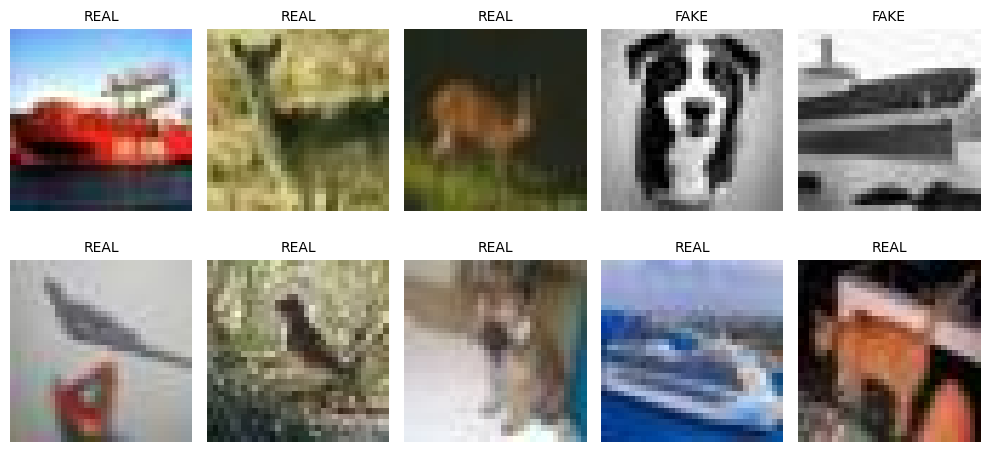

In [4]:
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        label = class_names[int(labels[i].numpy()[0])]
        plt.title(label, fontsize=10)
        plt.axis("off")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

## Step 5: Build the CNN

This architecture matches the **best-performing model from the CIFAKE paper**: two convolutional layers (32 filters each) followed by a single dense layer of 64 units, ending in a sigmoid output for binary classification (real vs. fake).

- **Conv2D + ReLU:** learns visual features (edges, textures, patterns).
- **MaxPooling:** shrinks the feature maps, keeping the strongest signals and reducing computation.
- **Flatten:** converts the 2D feature maps into a 1D vector for the dense layer.
- **Dense(64, relu):** combines the learned features to make a decision.
- **Dense(1, sigmoid):** outputs a single probability between 0 (FAKE) and 1 (REAL).

In [5]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,001 (328.13 KB)

 Trainable params: 84,001 (328.13 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 6: Train the model

We use `EarlyStopping` so training automatically stops if the validation loss stops improving, instead of you having to guess the right number of epochs. This also protects against overfitting.

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 77s 245ms/step - accuracy: 0.7408 - loss: 0.5050 - val_accuracy: 0.7841 - val_loss: 0.4395
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8271 - loss: 0.3958 - val_accuracy: 0.8422 - val_loss: 0.3635
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8512 - loss: 0.3447 - val_accuracy: 0.8594 - val_loss: 0.3231
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8671 - loss: 0.3121 - val_accuracy: 0.8767 - val_loss: 0.2923
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8786 - loss: 0.2842 - val_accuracy: 0.8819 - val_loss: 0.2765
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8924 - loss: 0.2589 - val_accuracy: 0.8928 - val_loss: 0.2517
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9005 - loss: 0.2405 - val_accuracy: 0.8952 - val_loss: 0.2472
Epoch 8/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9063 - loss: 0.2278 - val_accuracy:

## Step 7: Plot accuracy and loss curves



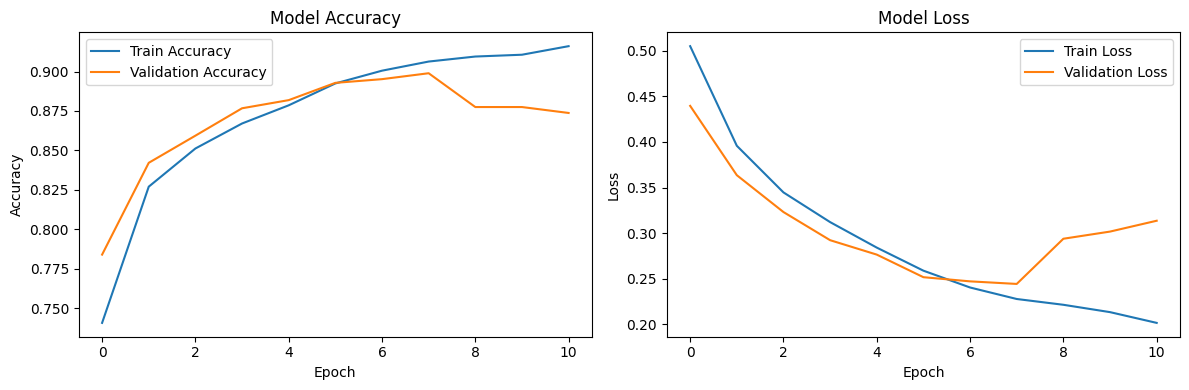

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("accuracy_loss_curves.png", dpi=150)
plt.show()

## Step 8: Evaluate on the test set



Classification Report:
              precision    recall  f1-score   support

        FAKE       0.88      0.92      0.90      3209
        REAL       0.92      0.88      0.90      3191

    accuracy                           0.90      6400
   macro avg       0.90      0.90      0.90      6400
weighted avg       0.90      0.90      0.90      6400



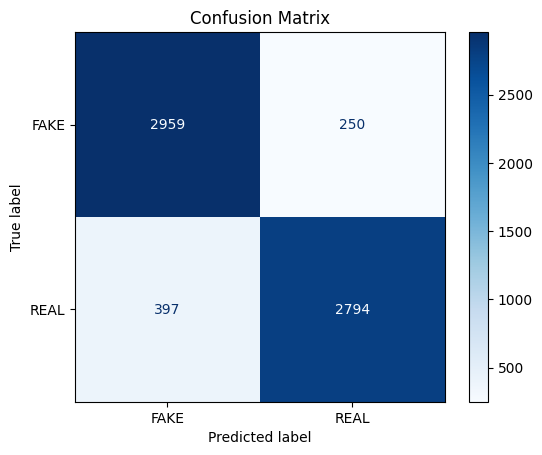

In [10]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy().astype(int).flatten())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## Step 9: Grad-CAM — explainability



Using layer: conv2d_1


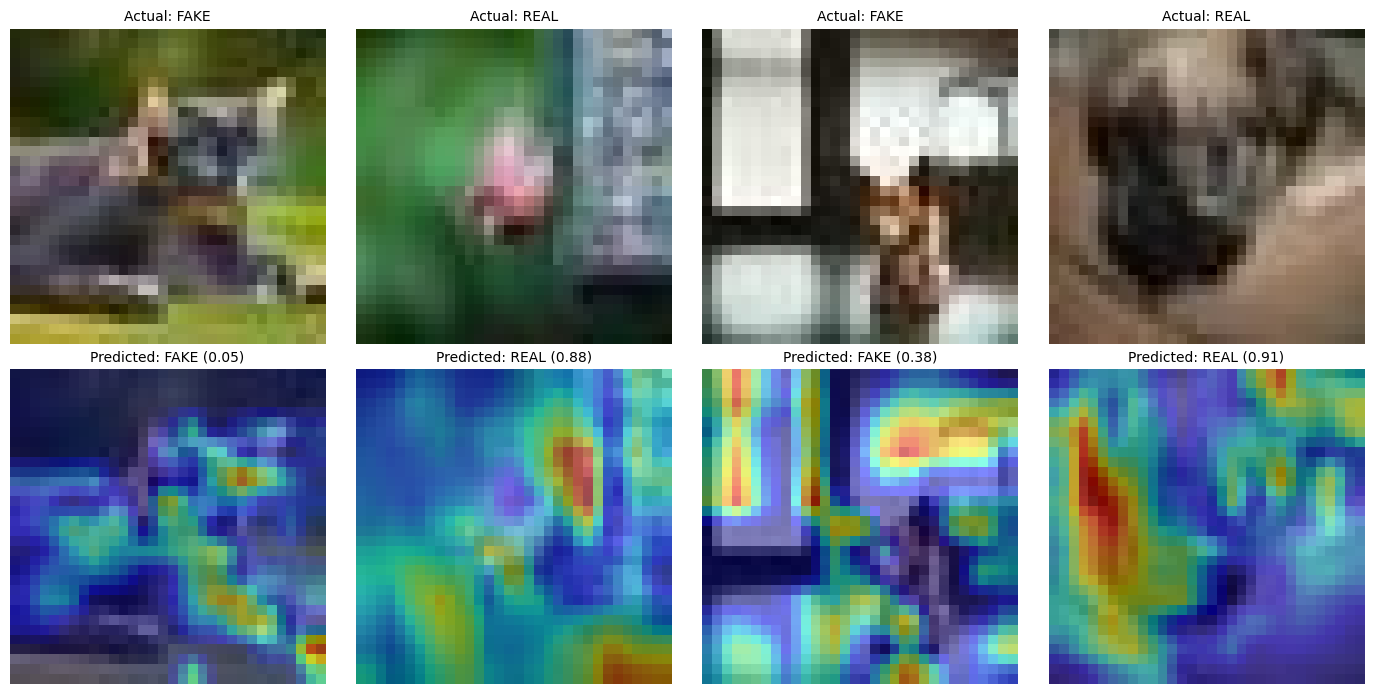

In [11]:
import matplotlib.cm as cm

last_conv_layer_name = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)][-1]
print("Using layer:", last_conv_layer_name)

# Rebuild as a functional model so Grad-CAM can access intermediate layer outputs
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inputs
conv_output = None
for layer in model.layers:
    x = layer(x)
    if layer.name == last_conv_layer_name:
        conv_output = x
grad_model = tf.keras.Model(inputs, [conv_output, x])

def make_gradcam_heatmap(img_array, grad_model):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.5):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    overlay = heatmap_colored * alpha + img * (1 - alpha)
    return overlay

for images, labels in test_ds.take(1):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i in range(4):
        img_array = tf.expand_dims(images[i], axis=0)
        heatmap = make_gradcam_heatmap(img_array, grad_model)
        overlay = display_gradcam(images[i].numpy(), heatmap)

        pred = model.predict(img_array, verbose=0)[0][0]
        predicted_label = class_names[int(pred > 0.5)]
        actual_label = class_names[int(labels[i].numpy()[0])]

        axes[0, i].imshow(images[i].numpy())
        axes[0, i].set_title(f"Actual: {actual_label}", fontsize=10)
        axes[0, i].axis('off')

        axes[1, i].imshow(overlay)
        axes[1, i].set_title(f"Predicted: {predicted_label} ({pred:.2f})", fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig("gradcam_examples.png", dpi=150)
    plt.show()

## Step 10: Save the model (optional, but useful)

Saves your trained model so you don't have to retrain it every time you reopen the notebook.

In [12]:
model.save("cifake_model.keras")
print("Model saved as cifake_model.keras")

Model saved as cifake_model.keras
